<div style="display: flex; gap: 10px;">
  <img src="../images/HOOPS_AI.jpg" style="width: 20%;">
   

# HOOPS AI: Use the Dataset Explorer to navigate the dataset


The `dataset` module provides a comprehensive framework for exploring, navigating, and loading CAD model datasets for machine learning applications. It consists of two primary components that work together to simplify data handling:

1. **DatasetExplorer** - For exploring and querying dataset contents
2. **DatasetLoader** - For loading and preparing datasets for machine learning training

These components are designed to work with the processed data from the `cadaccess` and `cadencoder` modules, as well as the outputs from the flow pipeline system. They provide high-level abstractions that allow users to focus on machine learning tasks rather than data handling complexities.

## DatasetExplorer

The `DatasetExplorer` class (`dataset_explorer.py`) provides methods for exploring and querying datasets stored in Zarr format (.dataset) with accompanying metadata (.infoset) in Parquet files. This class focuses on data discovery, filtering, and statistical analysis.

### Key Methods

#### Data Discovery and Metadata

- `available_groups() -> set`: Returns the set of available dataset groups (faces, edges, file, etc.)
- `get_descriptions(table_name: str, key_id: Optional[int] = None, use_wildchar: Optional[bool] = False) -> pd.DataFrame`: Retrieves metadata descriptions (labels, face types, edge types, etc.)
- `get_parquet_info_by_code(file_id_code: int)`: Returns rows from the Parquet file for a specific file ID code
- `get_file_info_all() -> pd.DataFrame`: Returns all file info from the Parquet metadata

#### Data Distribution Analysis

- `create_distribution(key: str, bins: int = 10, group: str = "faces") -> Dict[str, Any]`: Computes histograms of data distributions using Dask for parallel processing

#### Data Filtering and Selection

- `get_file_list(group: str, where: Callable[[xr.Dataset], xr.DataArray]) -> List[str]`: Returns file IDs matching a boolean filter condition
- `file_dataset(file_id_code: int, group: str) -> xr.Dataset`: Returns a subset of the dataset for a specific file
- `build_membership_matrix(group: str, key: str, bins_or_categories: Union[int, List, np.ndarray], as_counts: bool = False) -> tuple[np.ndarray, np.ndarray, np.ndarray]`: Builds a file-by-bin membership matrix for stratified splitting
- `decode_file_id_code(code: int) -> str`: Converts an integer file ID code to the original string identifier

In [1]:
import hoops_ai
import os
import sys

license_key = os.environ.get("HOOPS_AI_LICENSE")
if not license_key:
    sys.exit("HOOPS_AI_LICENSE environment variable is required.")

hoops_ai.set_license(license_key, validate=True)

------------------------------------------------------------
HOOPS AI
------------------------------------------------------------
  Platform      : Linux 6.17.0-23-generic
  Architecture  : x86_64
  Python        : 3.12.8
------------------------------------------------------------
  Core          : hoops-ai             1.1.0
  CAD Access    : hoops-exchange       26.2.0.dev7  (build: 1e11169 2026-03-23T17:47:19Z)
  Conversion    : hoops-converter      26.1.0.dev7  (build: 36742b6 2026-03-23T17:49:37Z)
  Insights      : hoops-web-viewer     26.1.0.dev5  (build: 25137b2 2026-03-23T13:36:51Z)
------------------------------------------------------------
[OK] HOOPS AI License: Valid


In [2]:
from hoops_ai.dataset import DatasetExplorer
import pathlib 
# Define paths
flow_name = "cadsynth10k"

flow_root_dir = pathlib.Path.cwd().parent.joinpath("packages", "flows", flow_name)
print(flow_root_dir)

parquet_file_path        = str(flow_root_dir.joinpath(f"{flow_name}.infoset"))
merged_store_path     = str(flow_root_dir.joinpath(f"{flow_name}.dataset"))
parquet_file_attribs  = str(flow_root_dir.joinpath(f"{flow_name}.attribset"))


explorer = DatasetExplorer(merged_store_path=merged_store_path, parquet_file_path=parquet_file_path, parquet_file_attribs=parquet_file_attribs)
explorer.print_table_of_contents()

INFO:To route to workers diagnostics web server please install jupyter-server-proxy: python -m pip install jupyter-server-proxy
INFO:State start
INFO:  Scheduler at:     tcp://127.0.0.1:45201
INFO:  dashboard at:  http://127.0.0.1:43935/status
INFO:Registering Worker plugin shuffle
INFO:        Start Nanny at: 'tcp://127.0.0.1:43307'


/home/maxime.marechal/Projects/HAI-Tutorials/packages/flows/cadsynth10k


INFO:Register worker <WorkerState 'tcp://127.0.0.1:45485', name: 0, status: init, memory: 0, processing: 0>
INFO:Starting worker compute stream, tcp://127.0.0.1:45485
INFO:Starting established connection to tcp://127.0.0.1:37848
INFO:Receive client connection: Client-82791388-49fd-11f1-b668-a0852779f716
INFO:Starting established connection to tcp://127.0.0.1:37856


[DatasetExplorer] Default local cluster started: <Client: 'tcp://127.0.0.1:45201' processes=1 threads=16, memory=7.45 GiB>


Processing file info:   0%|          | 0/9992 [00:00<?, ?it/s]


--- Dataset Table of Contents ---

LABELS_GROUP:
  FACE_LABELS_DATA: Shape: (275567,), Dims: ('faces',), Size: 275567
  FILE_ID_CODE_LABELS_DATA: Shape: (275567,), Dims: ('faces',), Size: 275567

EDGES_GROUP:
  EDGE_CONVEXITIES_DATA: Shape: (719473,), Dims: ('edge',), Size: 719473
  EDGE_DIHEDRAL_ANGLES_DATA: Shape: (719473,), Dims: ('edge',), Size: 719473
  EDGE_INDICES_DATA: Shape: (719473,), Dims: ('edge',), Size: 719473
  EDGE_LENGTHS_DATA: Shape: (719473,), Dims: ('edge',), Size: 719473
  EDGE_TYPES_DATA: Shape: (719473,), Dims: ('edge',), Size: 719473
  EDGE_U_GRIDS_DATA: Shape: (719473, 5, 6), Dims: ('edge', 'u', 'component'), Size: 21584190
  FILE_ID_CODE_EDGES_DATA: Shape: (719473,), Dims: ('edge',), Size: 719473

FACEFACE_GROUP:
  A3_DISTANCE_DATA: Shape: (8418913, 64), Dims: ('facepair', 'bin'), Size: 538810432
  D2_DISTANCE_DATA: Shape: (8418913, 64), Dims: ('facepair', 'bin'), Size: 538810432
  EXTENDED_ADJACENCY_DATA: Shape: (8418913,), Dims: ('facepair',), Size: 8418913

In [3]:
groups = explorer.available_groups()
print(groups)

{'faces', 'graph', 'edges', 'Labels', 'faceface'}


In [4]:
face_type_description = explorer.get_descriptions("face_types")
print(type(face_type_description), face_type_description)

<class 'pandas.core.frame.DataFrame'>        id        name description  table_name
9993    0       Plane     not set  face_types
9994    1    Cylinder     not set  face_types
9995    3      Sphere     not set  face_types
9996    2        Cone     not set  face_types
9997    4       Torus     not set  face_types
9998   14   Extrusion     not set  face_types
9999    5       Nurbs     not set  face_types
10000  13  Revolution     not set  face_types


In [5]:
# Get and print meta data information
file_id = 25
df_info = explorer.get_parquet_info_by_code(file_id)
#print(type(df_info), df_info)

In [6]:
# Access various dataset groups
file_datasetGroup = {grp: explorer.file_dataset(file_id_code=file_id, group=grp) for grp in groups}

print(f"Datasets (Table of Contents) for file ID '{file_id}':")
for grp, ds in file_datasetGroup.items():
    for name, da in ds.data_vars.items():
        print(f"  [{grp}] DATA: {name}, Shape: {da.shape}, Dims: {da.dims}, Size: {da.size}")
print()

file_dataset = file_datasetGroup["faces"]
print("type of file_data_arrays", type(file_dataset))

# Print the areas of each face
array_areas = file_dataset["face_areas"].data.compute()
print("type of array_areas", type(array_areas))
print("brep surfaces", array_areas.shape)

Datasets (Table of Contents) for file ID '25':
  [faces] DATA: face_areas, Shape: (14,), Dims: ('face',), Size: 14
  [faces] DATA: face_centroids, Shape: (14, 3), Dims: ('face', 'dim'), Size: 42
  [faces] DATA: face_discretization, Shape: (14, 25, 7), Dims: ('face', 'sample', 'component'), Size: 2450
  [faces] DATA: face_indices, Shape: (14,), Dims: ('face',), Size: 14
  [faces] DATA: face_loops, Shape: (14,), Dims: ('face',), Size: 14
  [faces] DATA: face_neighborscount, Shape: (14,), Dims: ('face',), Size: 14
  [faces] DATA: face_types, Shape: (14,), Dims: ('face',), Size: 14
  [faces] DATA: file_id_code_faces, Shape: (14,), Dims: ('face',), Size: 14
  [graph] DATA: edges_destination, Shape: (33,), Dims: ('edge',), Size: 33
  [graph] DATA: edges_source, Shape: (33,), Dims: ('edge',), Size: 33
  [graph] DATA: file_id_code_graph, Shape: (33,), Dims: ('edge',), Size: 33
  [graph] DATA: num_nodes, Shape: (33,), Dims: ('edge',), Size: 33
  [edges] DATA: edge_convexities, Shape: (33,), Dim

In [7]:
# This example assumes some familiarity with pandas and Dask.
discretization_data = file_dataset["face_discretization"].data.compute()


print("numpy array shape", discretization_data.shape)

numpy array shape (14, 25, 7)


In [8]:
#print(discretization_data)

In [9]:
explorer.get_file_info_all()

,name,id,description,subset,table_name
0,000080b997b0b9c0d859ae5b74addcf4_0,0,C:\Users\LuisSalazar.LY-LS-LEGION\Documents\da...,N/A,file_info
1,0003f988487ad0a1f1d50aed28f05dcf_0,1,C:\Users\LuisSalazar.LY-LS-LEGION\Documents\da...,N/A,file_info
2,001a37b15ea4bb7065f1166e643ffa68_0,2,C:\Users\LuisSalazar.LY-LS-LEGION\Documents\da...,N/A,file_info
3,001c8424af4a9f35cc2ab2444eeedf56_0,3,C:\Users\LuisSalazar.LY-LS-LEGION\Documents\da...,N/A,file_info
4,0026e60735c03ea48773ebc71ebe7367_0,4,C:\Users\LuisSalazar.LY-LS-LEGION\Documents\da...,N/A,file_info
...,...,...,...,...,...
9987,ffd53e1d4911d3d6b51c4f9b8f17f4e5_0,9987,C:\Users\LuisSalazar.LY-LS-LEGION\Documents\da...,N/A,file_info
9988,ffdd225c98a1627f37c5f1ae6730d816_0,9988,C:\Users\LuisSalazar.LY-LS-LEGION\Documents\da...,N/A,file_info
9989,ffdd519826ffe790c3fe27fff924ba72_0,9989,C:\Users\LuisSalazar.LY-LS-LEGION\Documents\da...,N/A,file_info
9990,ffe278e0d87153c84363f6769d93659c_0,9990,C:\Users\LuisSalazar.LY-LS-LEGION\Documents\da...,N/A,file_info


In [10]:
# Visualization libraries
import matplotlib.pyplot as plt

def print_distribution_info(dist, title="Distribution"):
    """Helper function to print and visualize distribution data."""
    list_filecount = list()
    for i, bin_files in enumerate(dist['file_id_codes_in_bins']):
        list_filecount.append(bin_files.size)

    dist['file_count'] =list_filecount
    # Visualization with matplotlib
    fig, ax = plt.subplots(figsize=(12, 4))
    
    bin_centers = 0.5 * (dist['bin_edges'][1:] + dist['bin_edges'][:-1])
    ax.bar(bin_centers, dist['file_count'], width=(dist['bin_edges'][1] - dist['bin_edges'][0]), 
           alpha=0.7, color='steelblue', edgecolor='black', linewidth=1)
    
    # Add file count annotations
    for i, count in enumerate(dist['file_count']):
        if count > 0:  # Only annotate non-empty bins
            ax.text(bin_centers[i], count + 0.5, f"{count}", 
                    ha='center', va='bottom', fontsize=8)
    
    ax.set_xlabel('Value')
    ax.set_ylabel('Count')
    ax.set_title(f'{title} Histogram')
    ax.grid(True, linestyle='--', alpha=0.7)
    
    plt.tight_layout()
    plt.show()

Variable 'face_labels' found in fallback group 'Labels'.
Face-label distribution created in 0.19 seconds



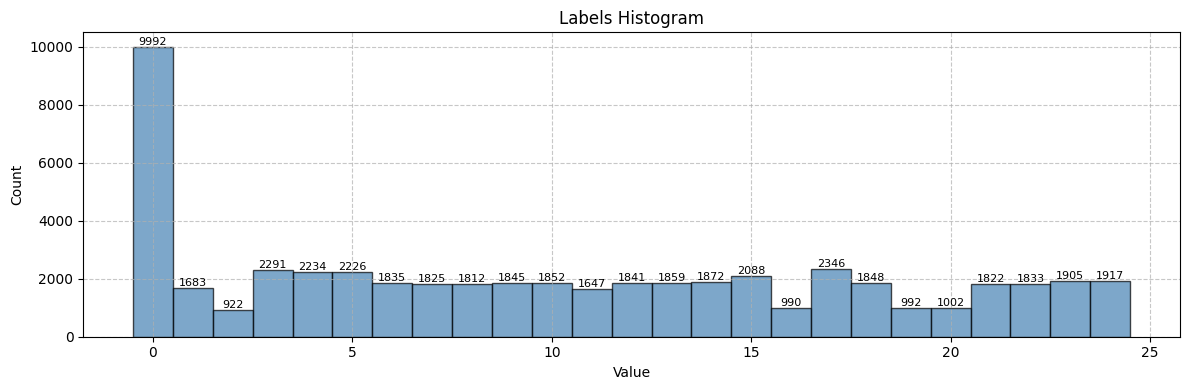

In [11]:
import time
start_time = time.time()
face_dist = explorer.create_distribution(key="face_labels", bins=None, group="faces")
print(f"Face-label distribution created in {(time.time() - start_time):.2f} seconds\n")
print_distribution_info(face_dist, title="Labels")


BRep face-count distribution created in 0.14 seconds



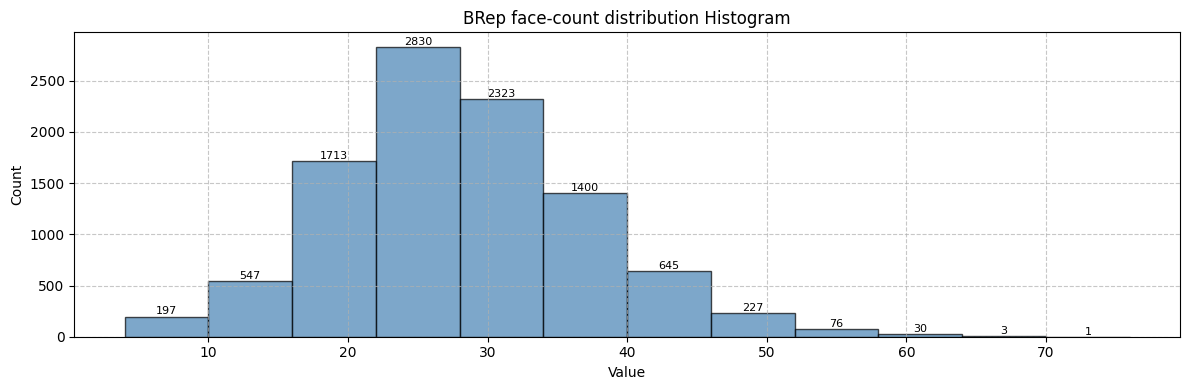

In [12]:
start_time = time.time()
dist = explorer.create_distribution(key="num_nodes", bins=12, group="graph")
print(f"BRep face-count distribution created in {(time.time() - start_time):.2f} seconds\n")
print_distribution_info(dist, title="BRep face-count distribution")

# Gather files that satisfy a given condition

In [13]:
start_time = time.time()

# condition
label_is_pipefittings = lambda ds: ds['face_labels'] == 15

filelist = explorer.get_file_list(group="Labels", where=label_is_pipefittings)
print(f"Filtering completed in {(time.time() - start_time):.2f} seconds")
print(f"Found {len(filelist)} files with face_labels == 15 (chamfer)\n")
print(filelist)

Filtering completed in 0.06 seconds
Found 2088 files with face_labels == 15 (chamfer)

[   0    2    3 ... 9984 9986 9987]


# Query data for single file

In [14]:
def demo_query_single_file(explorer, file_id):
    """Show how to access and query dataset details for a single file."""
    print("=== Single File Dataset Access ===")
    import time
    # Get and print parquet info
    df_info = explorer.get_parquet_info_by_code(file_id)
    print("File info:")
    for column in df_info.columns:
        print(f"Column: {column}")
        for value in df_info[column]:
            print(f"  {value}")
    print()

    # Access various dataset groups
    datasets = {grp: explorer.file_dataset(file_id_code=file_id, group=grp) for grp in groups}

    print(f"Datasets for file ID '{file_id}':")
    for grp, ds in datasets.items():
        for name, da in ds.data_vars.items():
            print(f"  [{grp}] VARIABLE: {name}, Shape: {da.shape}, Dims: {da.dims}, Size: {da.size}")
    print()

    # Query face discretization data for a specific face
    start_time = time.time()
    face_discretization_data = datasets["faces"]["face_discretization"].isel(face=2)
    print("Face discretization data for face index 2:")
    np_face_discretization = face_discretization_data.data.compute()
    print(f"Query took {(time.time() - start_time):.2f} seconds\n")

In [15]:
demo_query_single_file(explorer,file_id=4500)

=== Single File Dataset Access ===
File info:
Column: name
  7369dda24b8737152ef738380c3f76c9_0
Column: id
  4500
Column: description
  C:\Users\LuisSalazar.LY-LS-LEGION\Documents\data\Cadsynth_aag\step\00027023.stp
Column: subset
  N/A
Column: table_name
  file_info

Datasets for file ID '4500':
  [faces] VARIABLE: face_areas, Shape: (34,), Dims: ('face',), Size: 34
  [faces] VARIABLE: face_centroids, Shape: (34, 3), Dims: ('face', 'dim'), Size: 102
  [faces] VARIABLE: face_discretization, Shape: (34, 25, 7), Dims: ('face', 'sample', 'component'), Size: 5950
  [faces] VARIABLE: face_indices, Shape: (34,), Dims: ('face',), Size: 34
  [faces] VARIABLE: face_loops, Shape: (34,), Dims: ('face',), Size: 34
  [faces] VARIABLE: face_neighborscount, Shape: (34,), Dims: ('face',), Size: 34
  [faces] VARIABLE: face_types, Shape: (34,), Dims: ('face',), Size: 34
  [faces] VARIABLE: file_id_code_faces, Shape: (34,), Dims: ('face',), Size: 34
  [graph] VARIABLE: edges_destination, Shape: (92,), Di